
════════════════════════════════════════════════════════════════════════════════════════════════════
                        Таблица 3.1 — Первые 8 низших уровней энергии (N=40)                        
════════════════════════════════════════════════════════════════════════════════════════════════════
   (m,n)     │          E_DVR │        E_exact │       Ошибка │   Выр. │   C4v
────────────────────────────────────────────────────────────────────────────────────────────────────
   (1,1)     │      19.739209 │      19.739209 │     1.44e-12 │      1 │    A₁
(1,2)/(2,1)  │      49.348022 │      49.348022 │     2.13e-14 │      2 │     E
   (2,2)     │      78.956835 │      78.956835 │     1.36e-12 │      1 │    B₁
(1,3)/(3,1)  │      98.696044 │      98.696044 │     2.23e-12 │      2 │     E
(2,3)/(3,2)  │     128.304857 │     128.304857 │     1.48e-12 │      2 │     E
(1,4)/(4,1)  │     167.783275 │     167.783275 │     1.17e-12 │      2 │     E
   (3,3)     │     177.652879 │     177.65

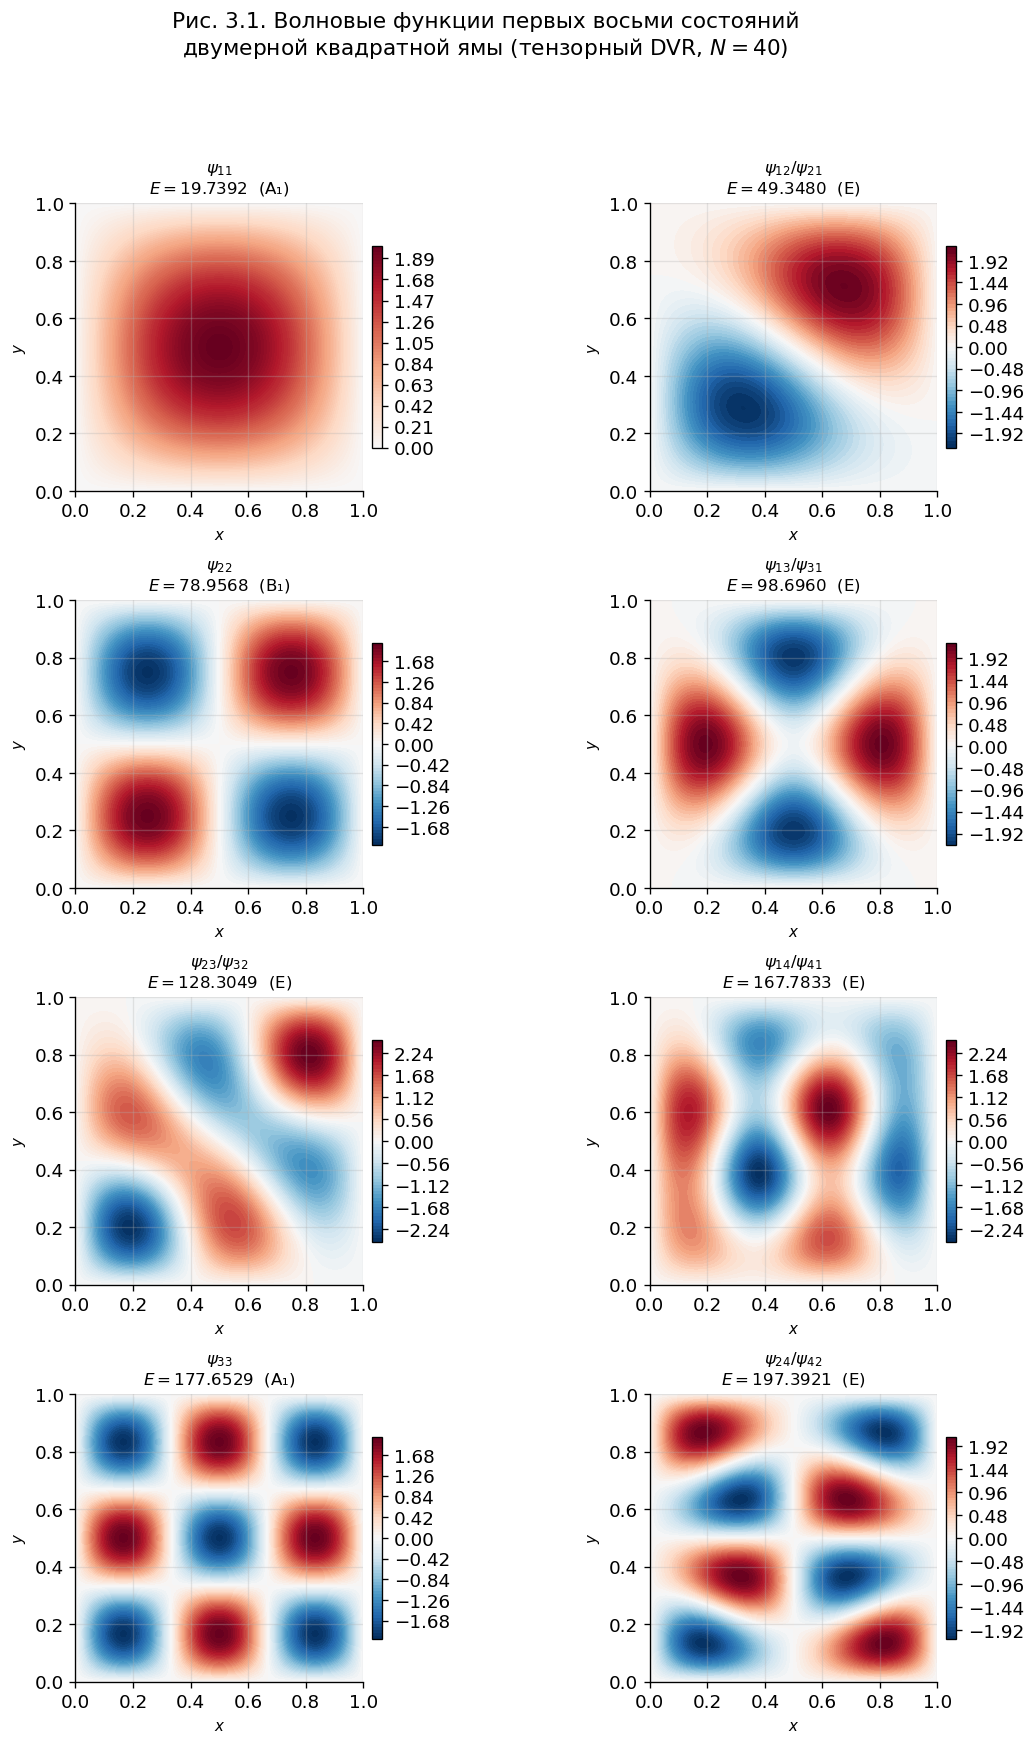

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import eigh
from itertools import product

# ================== ПАРАМЕТРЫ ==================
Nx = Ny = 40
L = 1.0
n_eig = 40

def build_T(N, length):
    k = np.arange(1, N + 1)
    n = np.arange(1, N + 1)
    U = np.sqrt(2.0 / (N + 1)) * np.sin(np.outer(k, n) * np.pi / (N + 1))
    E_n0 = (n * np.pi / length) ** 2
    T = U @ np.diag(E_n0) @ U.T
    return T, U

Tx, Ux = build_T(Nx, L)
Ty, Uy = build_T(Ny, L)

Ix, Iy = np.eye(Nx), np.eye(Ny)
T2d = np.kron(Tx, Iy) + np.kron(Ix, Ty)
H = T2d.copy()

E_dvr, c = eigh(H, subset_by_index=[0, n_eig - 1])

def exact_E(mn):
    m_q, n_q = mn
    return (np.pi ** 2) * (m_q**2 + n_q**2)

def c4v_irrep(m_q, n_q):
    if m_q == n_q:
        return "A₁" if (m_q % 2 == 1) else "B₁"
    return "E"

# ================== ТАБЛИЦА 3.1 (первые 8 уровней) ==================
levels = []
for m_q, n_q in product(range(1, 10), repeat=2):
    if m_q > n_q: 
        continue
    levels.append((exact_E((m_q, n_q)), m_q, n_q, 1 if m_q == n_q else 2, c4v_irrep(m_q, n_q)))

levels.sort(key=lambda x: x[0])

print("\n" + "═" * 100)
print(f"{'Таблица 3.1 — Первые 8 низших уровней энергии (N=40)':^100}")
print("═" * 100)
print(f"{'(m,n)':^12} │ {'E_DVR':>14} │ {'E_exact':>14} │ {'Ошибка':>12} │ {'Выр.':>6} │ {'C4v':>5}")
print("─" * 100)

dvr_ptr = 0
for i, (E_ex, m_q, n_q, deg, irrep) in enumerate(levels[:8]):
    E_dv = np.mean(E_dvr[dvr_ptr:dvr_ptr + deg])
    err = abs(E_dv - E_ex)
    label = f"({m_q},{n_q})" if m_q == n_q else f"({m_q},{n_q})/({n_q},{m_q})"
    print(f"{label:^12} │ {E_dv:>14.6f} │ {E_ex:>14.6f} │ {err:>12.2e} │ {deg:>6} │ {irrep:>5}")
    dvr_ptr += deg
print("═" * 100)

# ================== ВОЛНОВЫЕ ФУНКЦИИ ==================
x_fine = np.linspace(0, L, 160)
y_fine = np.linspace(0, L, 160)
n_x = np.arange(1, Nx + 1)
n_y = np.arange(1, Ny + 1)

Ux_fine = np.sqrt(2.0 / L) * np.sin(np.outer(n_x, np.pi * x_fine / L))
Uy_fine = np.sqrt(2.0 / L) * np.sin(np.outer(n_y, np.pi * y_fine / L))

def reconstruct_psi2d(eig_vec):
    C = eig_vec.reshape(Nx, Ny)
    C_nm = Ux.T @ C @ Uy
    return Ux_fine.T @ C_nm @ Uy_fine

fig = plt.figure(figsize=(11, 16))                    # выше и уже для 4×2
gs = gridspec.GridSpec(4, 2, hspace=0.38, wspace=0.28)

plot_idx = 0
dvr_ptr = 0

for E_ex, m_q, n_q, deg, irrep in levels[:8]:
    psi = reconstruct_psi2d(c[:, dvr_ptr])
    ax = fig.add_subplot(gs[plot_idx // 2, plot_idx % 2])   # ← 4 строки × 2 столбца
    vmax = np.max(np.abs(psi))
    im = ax.contourf(x_fine, y_fine, psi.T, levels=70, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    label = f"$\\psi_{{{m_q}{n_q}}}$" if m_q == n_q else f"$\\psi_{{{m_q}{n_q}}}/\\psi_{{{n_q}{m_q}}}$"
    ax.set_title(f"{label}\n$E={E_dvr[dvr_ptr]:.4f}$  ({irrep})", fontsize=10)
    ax.set_xlabel("$x$", fontsize=9)
    ax.set_ylabel("$y$", fontsize=9)
    ax.set_aspect("equal")
    dvr_ptr += deg
    plot_idx += 1

fig.suptitle("Рис. 3.1. Волновые функции первых восьми состояний\nдвумерной квадратной ямы (тензорный DVR, $N=40$)", 
             fontsize=13, y=0.98)
plt.savefig("dvr2d_wavefunctions_4x2.png", dpi=300, bbox_inches="tight")
plt.show()